In [1]:
from agents.v12.ppo_agent import PPOAgent, generate_eval_set
from agents.v12.ppo_opponent import PPOOpponent
import utils.board as b

In [2]:
agent = PPOAgent(
    curriculum_ratio=0.3,
    movement_ratio=0.5
)
agent.mate_pool = b.generate_mate_pool(10_000)
eval_fens = generate_eval_set(n=1000, seed=42)
agent.load("kqk_ppo_v12_v2")

opponent = PPOOpponent()

opponent.load("kqk_opponent_v2")
opponent.evaluate(
    white_agent=agent,
    n_episodes=1000
)

Using device: cuda
Generating 500 mate-in-1 positions...
Done.
Loaded eval set (1000 positions) ← /home/anass/School/chessMate/agents/v12/eval_set.json
Loaded ← models/kqk_ppo_v12_v2.pt
Using device: cuda
Loaded ← models/kqk_opponent_v2.pt

--- Opponent Eval (1000 eps) ---
  checkmate                     : 996
  insufficient_material         : 3
  threefold_repetition          : 1
  mean_steps                    : 7.6
  checkmate_rate                : 99.6%
  draw_rate                     : 0.4%


In [3]:
opponent.train(
    white_agent=agent,
    n_episodes=100_000
)

opponent.evaluate(
    white_agent=agent,
    n_episodes=1000
)

Episode 10416/100000  mean_return=-8.483
Episode 20336/100000  mean_return=-6.514
Episode 30256/100000  mean_return=-5.929
Episode 40176/100000  mean_return=-5.628
Episode 50096/100000  mean_return=-5.053
Episode 60016/100000  mean_return=-5.777
Episode 70432/100000  mean_return=-4.851
Episode 80352/100000  mean_return=-4.651
Episode 90272/100000  mean_return=-5.065
Episode 100192/100000  mean_return=-4.341
Training history saved → /home/anass/School/chessMate/agents/v12/opponent_train_history.json

--- Opponent Eval (1000 eps) ---
  checkmate                     : 768
  stalemate                     : 1
  threefold_repetition          : 231
  mean_steps                    : 9.1
  checkmate_rate                : 76.8%
  draw_rate                     : 23.2%


In [4]:
opponent.train(
    white_agent=agent,
    n_episodes=100_000
)

opponent.evaluate(
    white_agent=agent,
    n_episodes=1000
)

Episode 10416/100000  mean_return=-4.277
Episode 20336/100000  mean_return=-3.801
Episode 30256/100000  mean_return=-4.312
Episode 40176/100000  mean_return=-4.395
Episode 50096/100000  mean_return=-4.474
Episode 60016/100000  mean_return=-4.146
Episode 70432/100000  mean_return=-3.869
Episode 80352/100000  mean_return=-4.243
Episode 90272/100000  mean_return=-4.202
Episode 100192/100000  mean_return=-4.004
Training history saved → /home/anass/School/chessMate/agents/v12/opponent_train_history.json

--- Opponent Eval (1000 eps) ---
  checkmate                     : 703
  threefold_repetition          : 297
  mean_steps                    : 9.2
  checkmate_rate                : 70.3%
  draw_rate                     : 29.7%


In [5]:
opponent.train(
    white_agent=agent,
    n_episodes=100_000
)

opponent.evaluate(
    white_agent=agent,
    n_episodes=1000
)
opponent.save("kqk_opponent_v1")

Episode 10416/100000  mean_return=-3.890
Episode 20336/100000  mean_return=-3.659
Episode 30256/100000  mean_return=-4.302
Episode 40176/100000  mean_return=-3.373
Episode 50096/100000  mean_return=-3.054
Episode 60016/100000  mean_return=-3.022
Episode 70432/100000  mean_return=-3.007
Episode 80352/100000  mean_return=-2.585
Episode 90272/100000  mean_return=-2.806
Episode 100192/100000  mean_return=-3.150
Training history saved → /home/anass/School/chessMate/agents/v12/opponent_train_history.json

--- Opponent Eval (1000 eps) ---
  checkmate                     : 682
  insufficient_material         : 4
  threefold_repetition          : 314
  mean_steps                    : 9.4
  checkmate_rate                : 68.2%
  draw_rate                     : 31.8%
Saved → models/kqk_opponent_v1.pt


In [6]:
# Now train white agent against the trained opponent
# Baseline: how well does stage_3 do against the trained opponent?
agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)

agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

agent.train(
    n_episodes=100_000,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)
agent.evaluate_mate_in_one(n_episodes=1000, greedy=True)


--- Eval (1000 eps, opponent=agent) ---
  checkmate                     : 650
  missed_mate                   : 19
  queen_hang                    : 3
  threefold_repetition          : 328
  mean_steps                    : 10.2
  checkmate_rate                : 65.0%
Mate-in-1 accuracy (greedy): 602/1000 = 60.2%
Episode 10416/100000  mean_return=7.809
  [eval] ep=10416  checkmate=94.1%  mean_steps=9.1
Episode 20336/100000  mean_return=8.398
  [eval] ep=20336  checkmate=96.9%  mean_steps=9.4
Episode 30256/100000  mean_return=8.500
  [eval] ep=30256  checkmate=97.3%  mean_steps=9.5
Episode 40176/100000  mean_return=8.531
  [eval] ep=40176  checkmate=96.8%  mean_steps=9.1
Episode 50096/100000  mean_return=8.641
  [eval] ep=50096  checkmate=95.3%  mean_steps=9.1
Episode 60016/100000  mean_return=8.717
  [eval] ep=60016  checkmate=94.8%  mean_steps=9.0
Episode 70432/100000  mean_return=8.660
  [eval] ep=70432  checkmate=96.8%  mean_steps=9.1
Episode 80352/100000  mean_return=8.673
  [eval]

0.63

In [7]:
agent.train(
    n_episodes=100_000,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate(n_episodes=1000, opponent=opponent)
agent.evaluate_mate_in_one(n_episodes=1000, greedy=True)

Episode 10416/100000  mean_return=8.700
  [eval] ep=10416  checkmate=95.6%  mean_steps=9.0
Episode 20336/100000  mean_return=8.698
  [eval] ep=20336  checkmate=95.7%  mean_steps=9.1
Episode 30256/100000  mean_return=8.738
  [eval] ep=30256  checkmate=95.2%  mean_steps=9.0
Episode 40176/100000  mean_return=8.731
  [eval] ep=40176  checkmate=96.6%  mean_steps=9.0
Episode 50096/100000  mean_return=8.744
  [eval] ep=50096  checkmate=96.9%  mean_steps=9.1
Episode 60016/100000  mean_return=8.750
  [eval] ep=60016  checkmate=97.4%  mean_steps=9.1
Episode 70432/100000  mean_return=8.702
  [eval] ep=70432  checkmate=97.2%  mean_steps=8.8
Episode 80352/100000  mean_return=8.723
  [eval] ep=80352  checkmate=96.8%  mean_steps=8.9
Episode 90272/100000  mean_return=8.793
  [eval] ep=90272  checkmate=95.8%  mean_steps=8.9
Episode 100192/100000  mean_return=8.734
  [eval] ep=100192  checkmate=96.4%  mean_steps=8.8
Training history saved → /home/anass/School/chessMate/agents/v12/train_history.json

---

0.607

In [8]:
agent.train(
    n_episodes=100_000,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate(n_episodes=1000, opponent=opponent)
agent.evaluate_mate_in_one(n_episodes=1000, greedy=True)

agent.save("kqk_ppo_with_opponent_v1")

Episode 10416/100000  mean_return=8.748
  [eval] ep=10416  checkmate=97.2%  mean_steps=9.1
Episode 20336/100000  mean_return=8.773
  [eval] ep=20336  checkmate=96.1%  mean_steps=8.8
Episode 30256/100000  mean_return=8.714
  [eval] ep=30256  checkmate=96.0%  mean_steps=8.9
Episode 40176/100000  mean_return=8.721
  [eval] ep=40176  checkmate=96.3%  mean_steps=8.9
Episode 50096/100000  mean_return=8.787
  [eval] ep=50096  checkmate=96.1%  mean_steps=8.9
Episode 60016/100000  mean_return=8.804
  [eval] ep=60016  checkmate=95.1%  mean_steps=9.0
Episode 70432/100000  mean_return=8.690
  [eval] ep=70432  checkmate=94.7%  mean_steps=8.9
Episode 80352/100000  mean_return=8.774
  [eval] ep=80352  checkmate=96.2%  mean_steps=8.9
Episode 90272/100000  mean_return=8.770
  [eval] ep=90272  checkmate=95.9%  mean_steps=8.9
Episode 100192/100000  mean_return=8.775
  [eval] ep=100192  checkmate=95.3%  mean_steps=8.8
Training history saved → /home/anass/School/chessMate/agents/v12/train_history.json

---

In [9]:
# Second iteration — retrain opponent against the improved white agent
opponent.train(
    white_agent=agent,
    n_episodes=100_000
)

opponent.evaluate(white_agent=agent, n_episodes=1000)
opponent.save("kqk_opponent_v2_stage_2")

Episode 10416/100000  mean_return=-9.066
Episode 20336/100000  mean_return=-9.006
Episode 30256/100000  mean_return=-8.953
Episode 40176/100000  mean_return=-8.968
Episode 50096/100000  mean_return=-8.911
Episode 60016/100000  mean_return=-8.833
Episode 70432/100000  mean_return=-8.939
Episode 80352/100000  mean_return=-8.103
Episode 90272/100000  mean_return=-8.030
Episode 100192/100000  mean_return=-8.318
Training history saved → /home/anass/School/chessMate/agents/v12/opponent_train_history.json

--- Opponent Eval (1000 eps) ---
  checkmate                     : 952
  threefold_repetition          : 48
  mean_steps                    : 8.5
  checkmate_rate                : 95.2%
  draw_rate                     : 4.8%
Saved → models/kqk_opponent_v2_stage_2.pt


In [10]:
# Retrain white against the updated opponent
agent.train(
    n_episodes=100_000,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate(n_episodes=1000, opponent=opponent)
agent.evaluate_mate_in_one(n_episodes=1000, greedy=True)

agent.save("kqk_ppo_with_opponent_v1_stage_2")

Episode 10416/100000  mean_return=8.674
  [eval] ep=10416  checkmate=98.1%  mean_steps=8.9
Episode 20336/100000  mean_return=8.663
  [eval] ep=20336  checkmate=97.3%  mean_steps=8.8
Episode 30256/100000  mean_return=8.657
  [eval] ep=30256  checkmate=97.5%  mean_steps=9.0
Episode 40176/100000  mean_return=8.669
  [eval] ep=40176  checkmate=98.1%  mean_steps=8.9
Episode 50096/100000  mean_return=8.732
  [eval] ep=50096  checkmate=96.9%  mean_steps=8.7
Episode 60016/100000  mean_return=8.704
  [eval] ep=60016  checkmate=96.9%  mean_steps=8.9
Episode 70432/100000  mean_return=8.695
  [eval] ep=70432  checkmate=97.1%  mean_steps=8.7
Episode 80352/100000  mean_return=8.787
  [eval] ep=80352  checkmate=96.7%  mean_steps=8.8
Episode 90272/100000  mean_return=8.754
  [eval] ep=90272  checkmate=97.3%  mean_steps=8.8
Episode 100192/100000  mean_return=8.685
  [eval] ep=100192  checkmate=97.0%  mean_steps=8.8
Training history saved → /home/anass/School/chessMate/agents/v12/train_history.json

---

In [11]:
agent.train(
    n_episodes=100_000,
    n_workers=29,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)
agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

Episode 10208/100000  mean_return=8.762
  [eval] ep=10208  checkmate=96.3%  mean_steps=8.7
Episode 20416/100000  mean_return=8.717
  [eval] ep=20416  checkmate=97.1%  mean_steps=8.7
Episode 30160/100000  mean_return=8.743
  [eval] ep=30160  checkmate=97.4%  mean_steps=8.8
Episode 40368/100000  mean_return=8.838
  [eval] ep=40368  checkmate=97.1%  mean_steps=8.7
Episode 50112/100000  mean_return=8.730
  [eval] ep=50112  checkmate=96.7%  mean_steps=8.7
Episode 60320/100000  mean_return=8.727
  [eval] ep=60320  checkmate=97.0%  mean_steps=8.9
Episode 70064/100000  mean_return=8.750
  [eval] ep=70064  checkmate=95.6%  mean_steps=8.7
Episode 80272/100000  mean_return=8.745
  [eval] ep=80272  checkmate=95.9%  mean_steps=9.0
Episode 90016/100000  mean_return=8.763
  [eval] ep=90016  checkmate=97.0%  mean_steps=8.9
Episode 100224/100000  mean_return=8.780
  [eval] ep=100224  checkmate=96.3%  mean_steps=8.7
Training history saved → /home/anass/School/chessMate/agents/v12/train_history.json

---

0.618

In [12]:
agent.train(
    n_episodes=100_000,
    n_workers=29,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=10_000
)

agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)

Episode 10208/100000  mean_return=8.778
  [eval] ep=10208  checkmate=96.5%  mean_steps=8.8
Episode 20416/100000  mean_return=8.722
  [eval] ep=20416  checkmate=95.9%  mean_steps=8.7
Episode 30160/100000  mean_return=8.751
  [eval] ep=30160  checkmate=95.5%  mean_steps=8.8
Episode 40368/100000  mean_return=8.794
  [eval] ep=40368  checkmate=96.2%  mean_steps=8.9
Episode 50112/100000  mean_return=8.829
  [eval] ep=50112  checkmate=96.2%  mean_steps=8.8
Episode 60320/100000  mean_return=8.811
  [eval] ep=60320  checkmate=97.0%  mean_steps=8.9
Episode 70064/100000  mean_return=8.764
  [eval] ep=70064  checkmate=96.3%  mean_steps=8.8
Episode 80272/100000  mean_return=8.728
  [eval] ep=80272  checkmate=95.6%  mean_steps=8.8
Episode 90016/100000  mean_return=8.758
  [eval] ep=90016  checkmate=97.3%  mean_steps=8.9
Episode 100224/100000  mean_return=8.786
  [eval] ep=100224  checkmate=97.9%  mean_steps=8.8
Training history saved → /home/anass/School/chessMate/agents/v12/train_history.json
Mate

In [13]:
agent.train(
    n_episodes=200_000,
    n_workers=29,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=20_000
)

agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)

Episode 20416/200000  mean_return=8.830
  [eval] ep=20416  checkmate=96.4%  mean_steps=8.8
Episode 40368/200000  mean_return=8.854
  [eval] ep=40368  checkmate=97.4%  mean_steps=8.7
Episode 60320/200000  mean_return=8.844
  [eval] ep=60320  checkmate=96.5%  mean_steps=8.9
Episode 80272/200000  mean_return=8.790
  [eval] ep=80272  checkmate=95.9%  mean_steps=8.7
Episode 100224/200000  mean_return=8.882
  [eval] ep=100224  checkmate=96.4%  mean_steps=8.9
Episode 120176/200000  mean_return=8.878
  [eval] ep=120176  checkmate=96.4%  mean_steps=8.8
Episode 140128/200000  mean_return=8.800
  [eval] ep=140128  checkmate=97.0%  mean_steps=8.7
Episode 160080/200000  mean_return=8.843
  [eval] ep=160080  checkmate=97.2%  mean_steps=8.7
Episode 180032/200000  mean_return=8.764
  [eval] ep=180032  checkmate=95.4%  mean_steps=8.9
Episode 200448/200000  mean_return=8.777
  [eval] ep=200448  checkmate=96.2%  mean_steps=8.9
Training history saved → /home/anass/School/chessMate/agents/v12/train_history

In [14]:
agent.train(
    n_episodes=200_000,
    n_workers=29,
    opponent=opponent,
    eval_fens=eval_fens,
    eval_every=20_000
)

agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)

Episode 20416/200000  mean_return=8.813
  [eval] ep=20416  checkmate=96.1%  mean_steps=8.9
Episode 40368/200000  mean_return=8.814
  [eval] ep=40368  checkmate=96.8%  mean_steps=8.9
Episode 60320/200000  mean_return=8.792
  [eval] ep=60320  checkmate=95.9%  mean_steps=9.0
Episode 80272/200000  mean_return=8.766
  [eval] ep=80272  checkmate=96.1%  mean_steps=8.8
Episode 100224/200000  mean_return=8.877
  [eval] ep=100224  checkmate=96.5%  mean_steps=8.8
Episode 120176/200000  mean_return=8.909
  [eval] ep=120176  checkmate=97.4%  mean_steps=8.8
Episode 140128/200000  mean_return=8.840
  [eval] ep=140128  checkmate=97.1%  mean_steps=9.0
Episode 160080/200000  mean_return=8.783
  [eval] ep=160080  checkmate=96.5%  mean_steps=8.8
Episode 180032/200000  mean_return=8.865
  [eval] ep=180032  checkmate=95.7%  mean_steps=8.9
Episode 200448/200000  mean_return=8.845
  [eval] ep=200448  checkmate=96.4%  mean_steps=8.9
Training history saved → /home/anass/School/chessMate/agents/v12/train_history

In [15]:
agent.evaluate_mate_in_one(
    n_episodes=1000,
    greedy=True
)

agent.evaluate(
    n_episodes=1000,
    opponent=opponent
)

Mate-in-1 accuracy (greedy): 620/1000 = 62.0%

--- Eval (1000 eps, opponent=agent) ---
  checkmate                     : 990
  missed_mate                   : 10
  mean_steps                    : 8.0
  checkmate_rate                : 99.0%


## Training curves

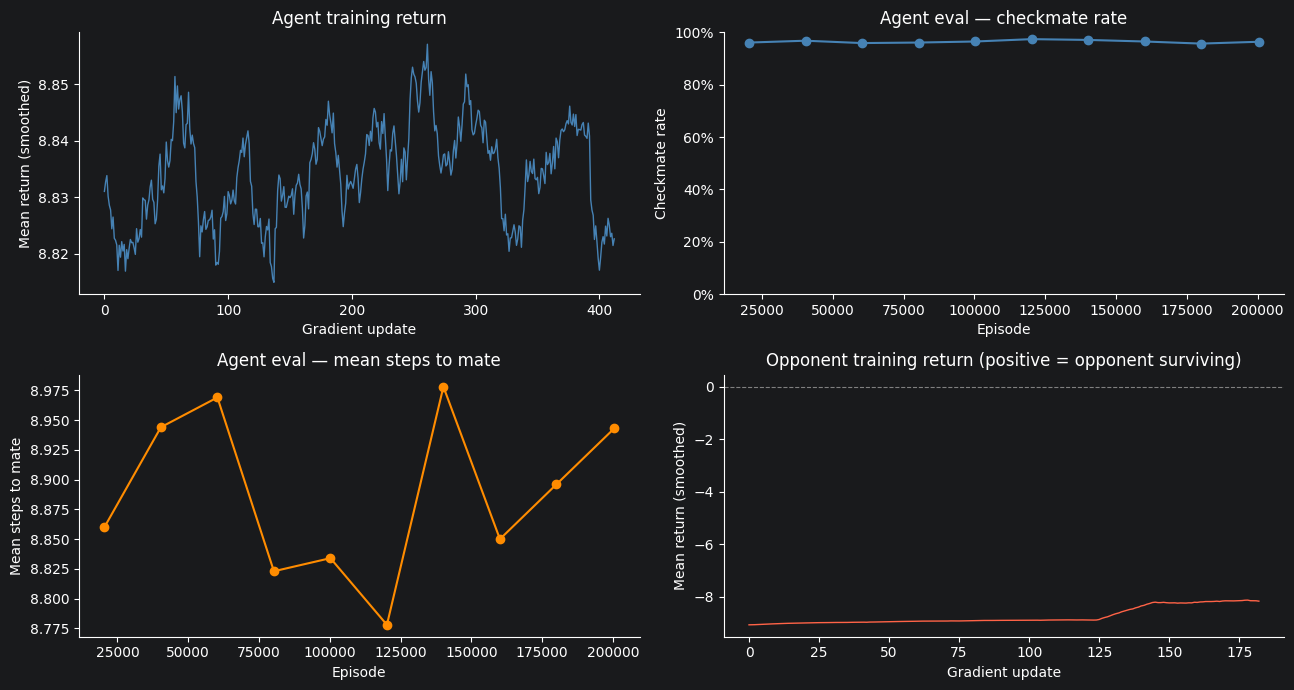

In [16]:
import json, os
import numpy as np
import matplotlib.pyplot as plt

_AGENT_DIR = os.path.join(os.getcwd(), "..", "..", "agents", "v12")

def _load(fname):
    p = os.path.join(_AGENT_DIR, fname)
    with open(p) as f:
        return json.load(f)

agent_hist    = _load("train_history.json")
opponent_hist = _load("opponent_train_history.json")

train_rewards = np.array(agent_hist["train_rewards"])
eval_history  = agent_hist["eval_history"]
opp_rewards   = np.array(opponent_hist["train_rewards"])

def _smooth(x, w=20):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# --- Agent: mean return per gradient update ---
ax = axes[0, 0]
ax.plot(_smooth(train_rewards), color="steelblue", linewidth=1)
ax.set_xlabel("Gradient update")
ax.set_ylabel("Mean return (smoothed)")
ax.set_title("Agent training return")
ax.spines[["top", "right"]].set_visible(False)

# --- Agent: eval checkmate rate over episodes ---
ax = axes[0, 1]
eps   = [e["episode"]        for e in eval_history]
rates = [e["checkmate_rate"] for e in eval_history]
ax.plot(eps, rates, marker="o", color="steelblue", linewidth=1.5)
ax.set_xlabel("Episode")
ax.set_ylabel("Checkmate rate")
ax.set_ylim(0, 1)
ax.set_title("Agent eval — checkmate rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{100*y:.0f}%"))
ax.spines[["top", "right"]].set_visible(False)

# --- Agent: eval mean steps over episodes ---
ax = axes[1, 0]
steps = [e["mean_steps"] for e in eval_history]
ax.plot(eps, steps, marker="o", color="darkorange", linewidth=1.5)
ax.set_xlabel("Episode")
ax.set_ylabel("Mean steps to mate")
ax.set_title("Agent eval — mean steps to mate")
ax.spines[["top", "right"]].set_visible(False)

# --- Opponent: mean return per gradient update ---
ax = axes[1, 1]
ax.plot(_smooth(opp_rewards), color="tomato", linewidth=1)
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Gradient update")
ax.set_ylabel("Mean return (smoothed)")
ax.set_title("Opponent training return (positive = opponent surviving)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()